## 1. Data Loading & Merging

In [47]:
import pandas as pd
import numpy as np

# Load Transaction Data
train_transaction = pd.read_csv('d:/IMT/IMTM2S1/AML/ieee-fraud-detection/input/train_transaction.csv')
test_transaction = pd.read_csv('d:/IMT/IMTM2S1/AML/ieee-fraud-detection/input/test_transaction.csv')

# Load Identity Data
train_identity = pd.read_csv('d:/IMT/IMTM2S1/AML/ieee-fraud-detection/input/train_identity.csv')
test_identity = pd.read_csv('d:/IMT/IMTM2S1/AML/ieee-fraud-detection/input/test_identity.csv')

print("Dataset Shapes:")
print(f"Train Transaction: {train_transaction.shape}")
print(f"Train Identity: {train_identity.shape}")
print(f"Test Transaction: {test_transaction.shape}")
print(f"Test Identity: {test_identity.shape}")

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
# Merge Transaction and Identity Data
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

# Free memory
del train_transaction, train_identity, test_transaction, test_identity

In [ ]:
#Detailed Column Analysis for train_transaction.csv
def analyze_columns(df, name):
    print(f"\n{'='*50}")
    print(f"Column Analysis of {name}")
    print(f"{'='*50}")
    
    for column in df.columns:
        print(f"\nColumn: {column}")
        print(f"Data Type: {df[column].dtype}")
        print(f"Missing Values: {df[column].isnull().sum()} ({(df[column].isnull().mean() * 100):.2f}%)")
        
        # Unique values
        unique_values = df[column].nunique()
        print(f"Unique Values: {unique_values}")
        
        # Sample values
        print(f"Sample Values: {df[column].dropna().unique()[:5]}")
        
        # Consideration for model
        if unique_values < 10:
            print("Consideration: Categorical feature, consider encoding.")
        elif df[column].dtype in ['int64', 'float64']:
            print("Consideration: Numerical feature, consider scaling.")
        else:
            print("Consideration: High cardinality or non-numeric, consider feature engineering or exclusion.")

# Analyze train_transaction.csv
analyze_columns(train, "Train Data")


Column Analysis of Train Data

Column: TransactionID
Data Type: int64
Missing Values: 0 (0.00%)
Unique Values: 590540
Sample Values: [2987000 2987001 2987002 2987003 2987004]
Consideration: Numerical feature, consider scaling.

Column: isFraud
Data Type: int64
Missing Values: 0 (0.00%)
Unique Values: 2
Sample Values: [0 1]
Consideration: Categorical feature, consider encoding.

Column: TransactionDT
Data Type: int64
Missing Values: 0 (0.00%)
Unique Values: 573349
Sample Values: [86400 86401 86469 86499 86506]
Consideration: Numerical feature, consider scaling.

Column: TransactionAmt
Data Type: float64
Missing Values: 0 (0.00%)
Unique Values: 20902
Sample Values: [68.5 29.  59.  50.  49. ]
Consideration: Numerical feature, consider scaling.

Column: ProductCD
Data Type: object
Missing Values: 0 (0.00%)
Unique Values: 5
Sample Values: ['W' 'H' 'C' 'S' 'R']
Consideration: Categorical feature, consider encoding.

Column: card1
Data Type: int64
Missing Values: 0 (0.00%)
Unique Values: 135

In [ ]:
#Analyze Transaction Data
def analyze_dataframe(df, name):
    print(f"\n{'='*50}")
    print(f"Analysis of {name}")
    print(f"{'='*50}")
    
    # Basic info
    print("\nBasic Information:")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    
    # Data types
    print("\nData Types Distribution:")
    print(df.dtypes.value_counts())
    
    # Missing values
    missing_values = df.isnull().sum()
    missing_percentages = (missing_values / len(df)) * 100
    missing_info = pd.DataFrame({
        'Missing Values': missing_values,
        'Missing Percentage': missing_percentages
    })
    print("\nMissing Values Analysis:")
    print(missing_info[missing_info['Missing Values'] > 0].sort_values('Missing Percentage', ascending=False))

In [ ]:
# Analyze each dataset
analyze_dataframe(train, "Train Data")
analyze_dataframe(test, "Test Data")


Analysis of Train Data

Basic Information:
Rows: 590540, Columns: 434

Data Types Distribution:
float64    399
object      31
int64        4
Name: count, dtype: int64

Missing Values Analysis:
       Missing Values  Missing Percentage
id_24          585793           99.196159
id_25          585408           99.130965
id_07          585385           99.127070
id_08          585385           99.127070
id_21          585381           99.126393
...               ...                 ...
V285               12            0.002032
V284               12            0.002032
V280               12            0.002032
V279               12            0.002032
V312               12            0.002032

[414 rows x 2 columns]

Analysis of Test Data

Basic Information:
Rows: 506691, Columns: 433

Data Types Distribution:
float64    399
object      31
int64        3
Name: count, dtype: int64

Missing Values Analysis:
       Missing Values  Missing Percentage
id-24          501951           99.064519
i

## 2. Exploratory Data Analysis (EDA)

### 2.1 Class Distribution

In [ ]:
#Analyze Target Variable
print("\nFraud Distribution:")
fraud_dist = train['isFraud'].value_counts(normalize=True)
print(fraud_dist)


Fraud Distribution:
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_7164\2260546565.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=train, palette='coolwarm')


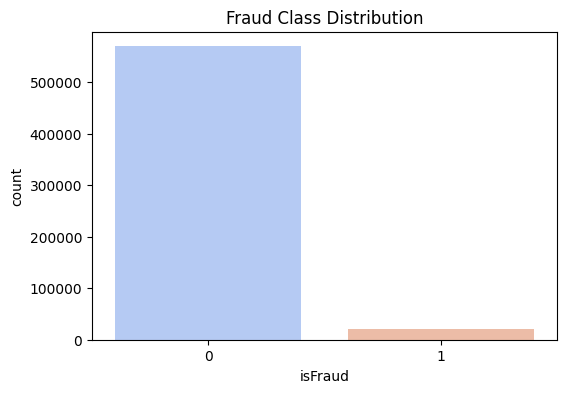

Fraud Rate: 3.50%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=train, palette='coolwarm')
plt.title('Fraud Class Distribution')
plt.show()

print(f"Fraud Rate: {train['isFraud'].mean()*100:.2f}%")

Observation: Severe class imbalance (3.5% fraud).

### 2.2 Transaction Amount Analysis

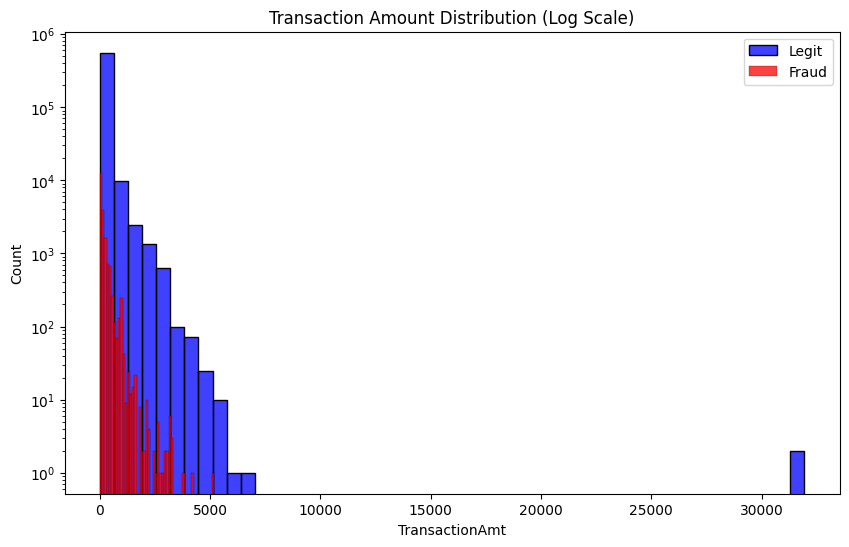

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(train[train['isFraud']==0]['TransactionAmt'], color='blue', label='Legit', bins=50)
sns.histplot(train[train['isFraud']==1]['TransactionAmt'], color='red', label='Fraud', bins=50)
plt.yscale('log')
plt.title('Transaction Amount Distribution (Log Scale)')
plt.legend()
plt.show()

Observation: Fraudulent transactions may involve smaller amounts.

### 2.3 Categorical Features

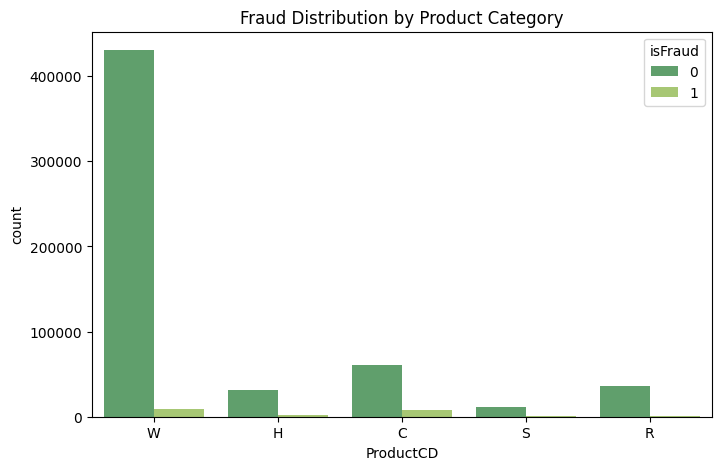

In [ ]:
# ProductCD Analysis
plt.figure(figsize=(8,5))
sns.countplot(x='ProductCD', hue='isFraud', data=train, palette='summer')
plt.title('Fraud Distribution by Product Category')
plt.show()

# DeviceType Analysis
# plt.figure(figsize=(8,5))
# sns.countplot(x='DeviceType', hue='isFraud', data=train, palette='Set1')
# plt.title('Fraud Distribution by Device Type')
# plt.show()

Observation:

Product W has the highest fraud rate.
- ProductCD W is being used more thus it has maximum percentage of transactions, with 73 % for non fraud cases, and 1.52 % for fraud cases
- Second highest used productCode is C, with 10.2 % used for non - fraudulent cases and 1/36 % for fraudulent cases

Mobile devices show higher fraud likelihood.

C:\Users\USER\AppData\Local\Temp\ipykernel_7164\2741252466.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  axes2 = sns.barplot(x=tmp['dayofweek'],y=tmp['Number of transactions'],palette='summer')


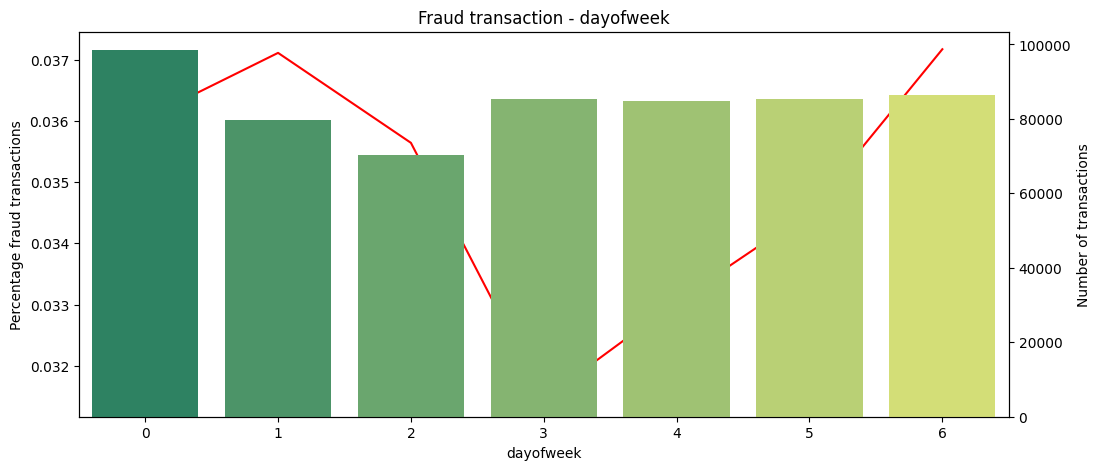

In [ ]:
train['dayofweek'] = (train['TransactionDT']//(60*60*24)-1)%7
tmp = train[['isFraud','dayofweek']].groupby(by=['dayofweek']).mean().reset_index() \
            .rename(columns={'isFraud':'Percentage fraud transactions'})

tmp_count = train[['TransactionID','dayofweek']].groupby(by=['dayofweek']).count().reset_index() \
            .rename(columns={'TransactionID':'Number of transactions'})
tmp = tmp.merge(tmp_count,on=['dayofweek'])




fig, axes = plt.subplots(figsize=(12,5))
axes = sns.lineplot(x=tmp['dayofweek'],y=tmp['Percentage fraud transactions'],color='r')
axes2 = axes.twinx()
axes2 = sns.barplot(x=tmp['dayofweek'],y=tmp['Number of transactions'],palette='summer')
axes.set_title('Fraud transaction - dayofweek')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_7164\2541080216.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  axes2 = sns.barplot(x=tmp['hour'],y=tmp['Number of transactions'],palette='summer')


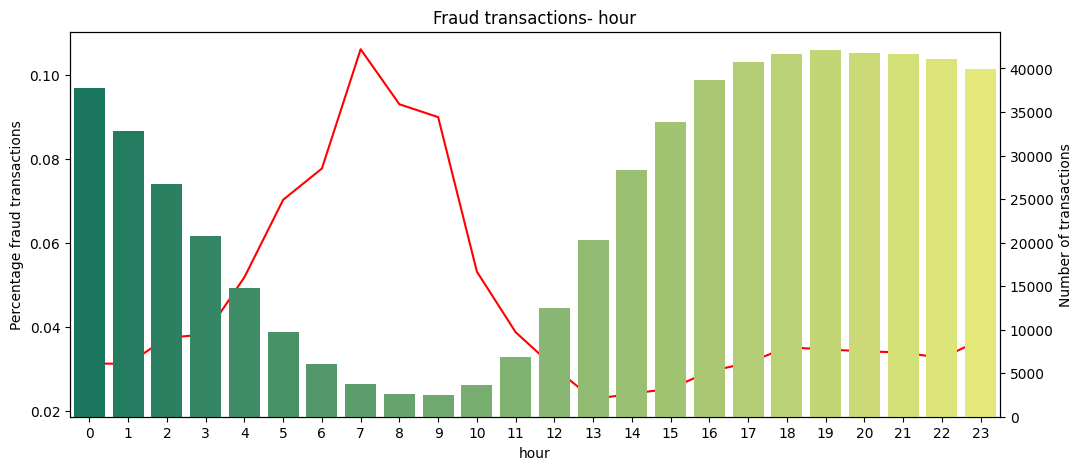

In [ ]:
train['hour'] = (train['TransactionDT']//(60*60))%24
tmp = train[['isFraud','hour']].groupby(by=['hour']).mean().reset_index() \
            .rename(columns={'isFraud':'Percentage fraud transactions'})

tmp_count = train[['TransactionID','hour']].groupby(by=['hour']).count().reset_index() \
            .rename(columns={'TransactionID':'Number of transactions'})
tmp = tmp.merge(tmp_count,on=['hour'])




fig, axes = plt.subplots(figsize=(12,5))
axes = sns.lineplot(x=tmp['hour'],y=tmp['Percentage fraud transactions'],color='r')
axes2 = axes.twinx()
axes2 = sns.barplot(x=tmp['hour'],y=tmp['Number of transactions'],palette='summer')
axes.set_title('Fraud transactions- hour')
plt.show()


Observation:
- Fraud rate decreases in the afternoon and is highest in the morning
- Fraud rate tends to increase from the beginning of the week, tends to decrease on Friday and Sunday.

In [ ]:
def labels(ax, df, xytext=(0, 0)):
    for bar in ax.patches: 
        ax.annotate('%{:.2f}\n{:.0f}'.format(100*bar.get_height()/len(df),bar.get_height()), (bar.get_x() + bar.get_width() / 2,  
                    bar.get_height()), ha='center', va='center', 
                    size=11, xytext=xytext, 
                    textcoords='offset points')
        
def plot_col(col, df, figsize=(20,6)):

    tmp = pd.crosstab(df[col], df['isFraud'], normalize='index') * 100
    tmp = tmp.reset_index()
    tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

    ax = sns.countplot(x=col, data=df, hue='isFraud', 
                  order=np.sort(df[col].dropna().unique()), palette='summer'
                  )
    ax.tick_params(axis='x', rotation=90)
    labels(ax,df[col].dropna(),(0, 0))

    ax.grid()
    plt.show()

In [ ]:
cards = [col for col in train.columns if 'card' in col]
train[cards].head()

,card1,card2,card3,card4,card5,card6
0,13926,NaN,150.0,discover,142.0,credit
1,2755,404.0,150.0,mastercard,102.0,credit
2,4663,490.0,150.0,visa,166.0,debit
3,18132,567.0,150.0,mastercard,117.0,debit
4,4497,514.0,150.0,mastercard,102.0,credit


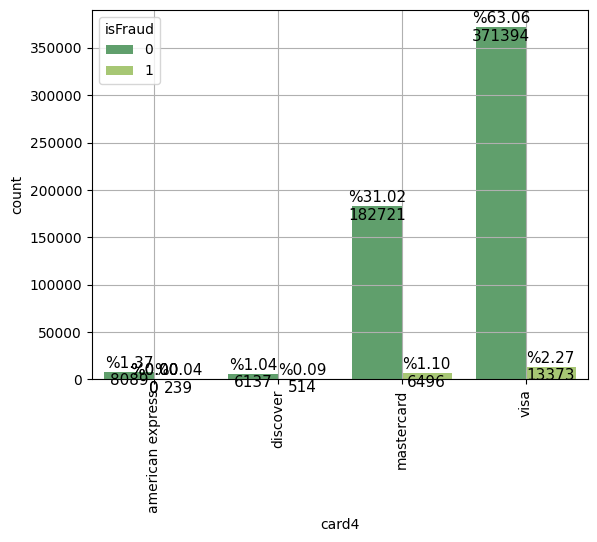

In [ ]:
plot_col('card4', df=train)

- We can infer that Visa Card is the most used card for transactions, with about 63% being used for fraudulent transactions.
- MasterCard is the second most used card with 31% being used for fraudulent transactions, others are less than 3
%

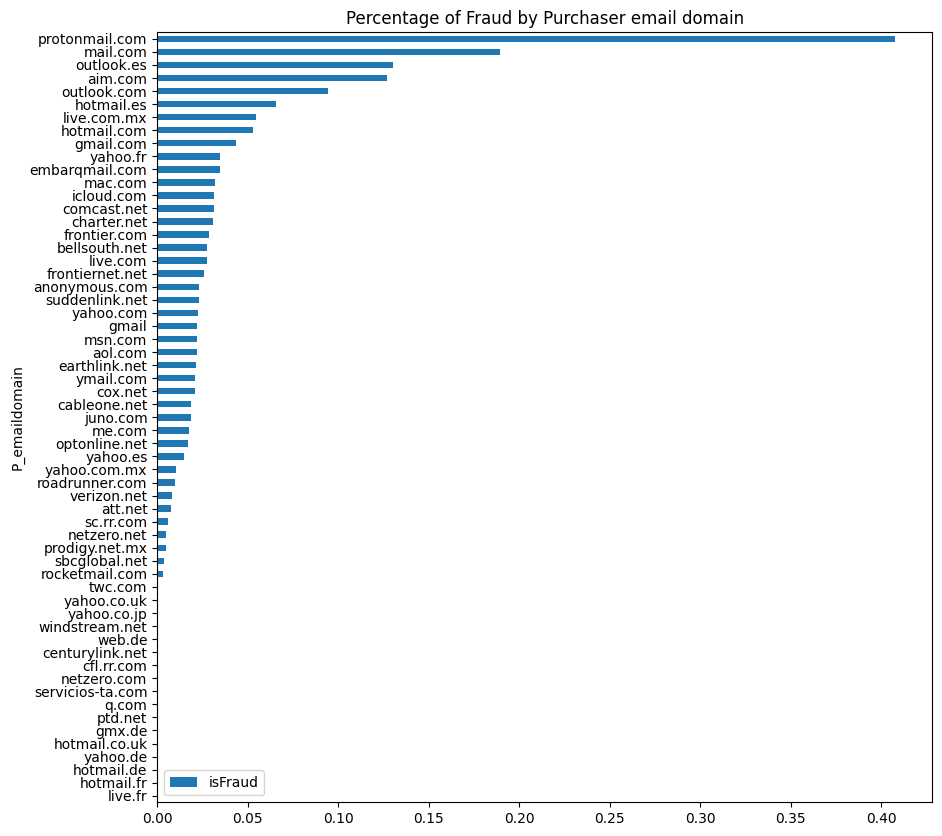

In [ ]:
train[['P_emaildomain','isFraud']].groupby(by=['P_emaildomain']).mean() \
        .sort_values(by=['isFraud']).plot(kind='barh',
        figsize=(10, 10),
         title='Percentage of Fraud by Purchaser email domain')
plt.show()

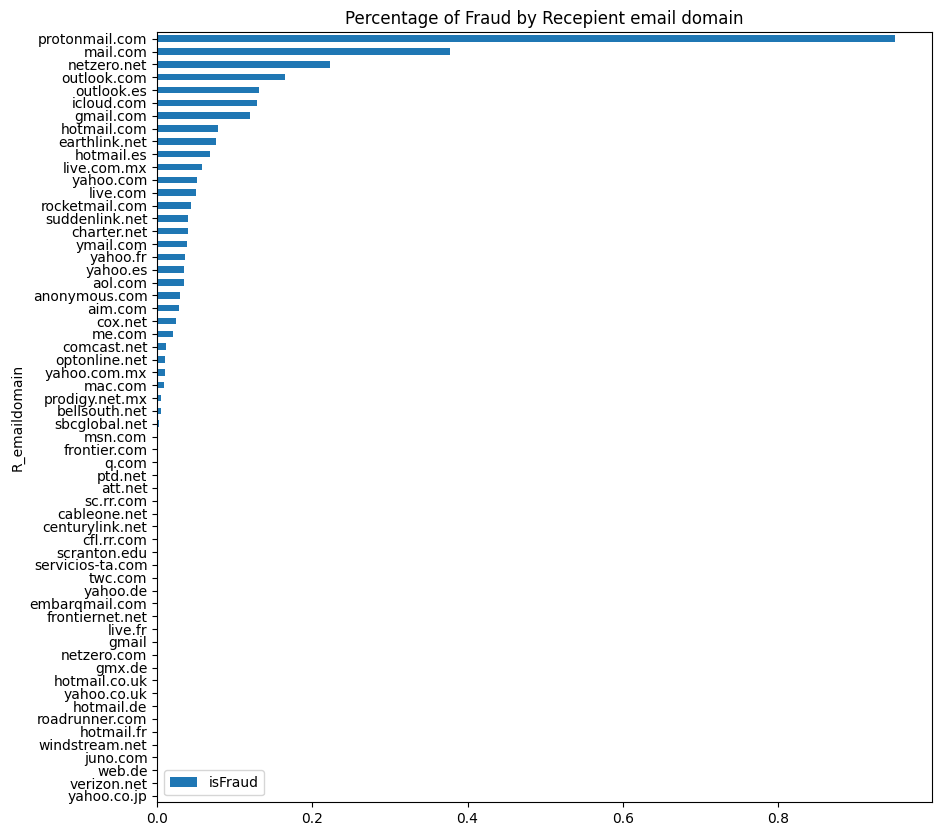

In [ ]:
train[['R_emaildomain','isFraud']].groupby(by=['R_emaildomain']).mean() \
        .sort_values(by=['isFraud']).plot(kind='barh',
        figsize=(10, 10),
         title='Percentage of Fraud by Recepient email domain')
plt.show()

The Most fraudaulent transactions come from domain name 'protonmail.com' which is more than 40%.

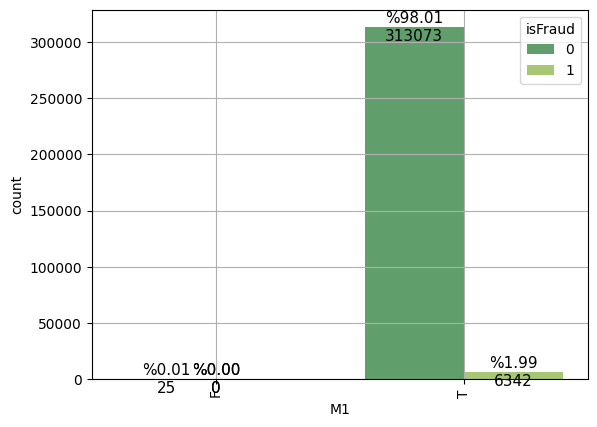

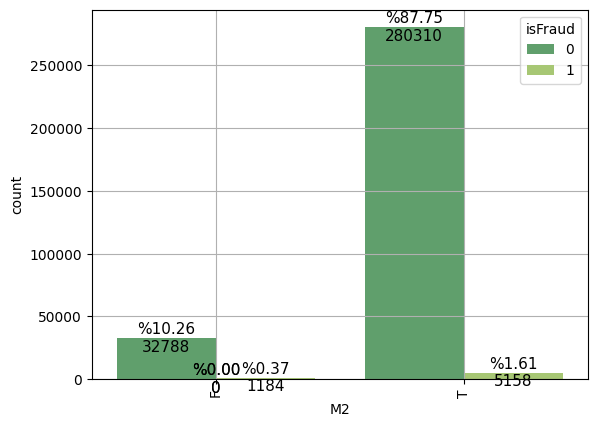

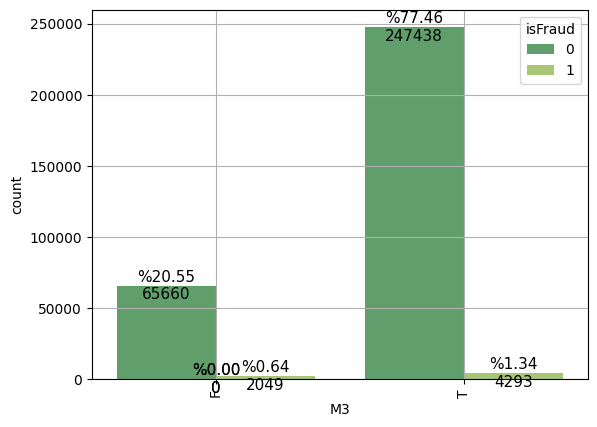

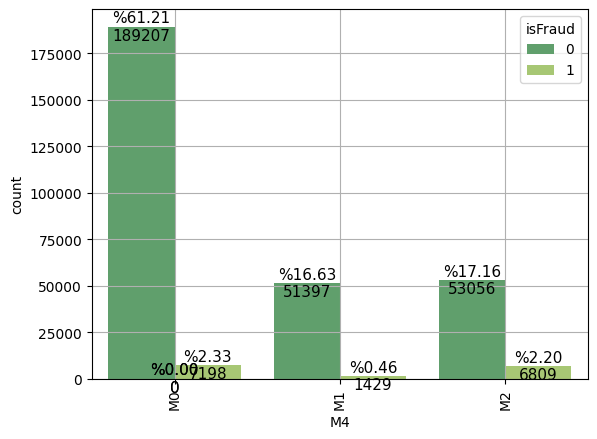

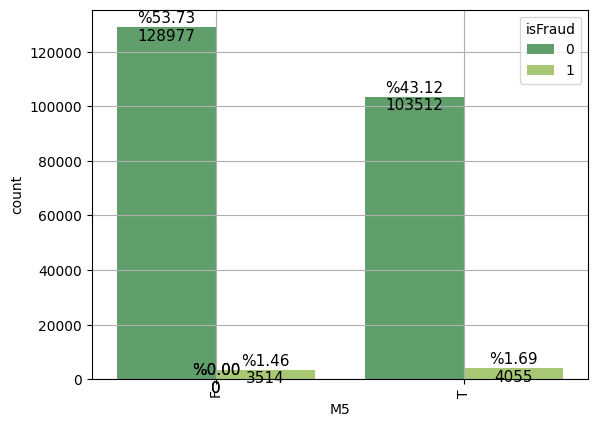

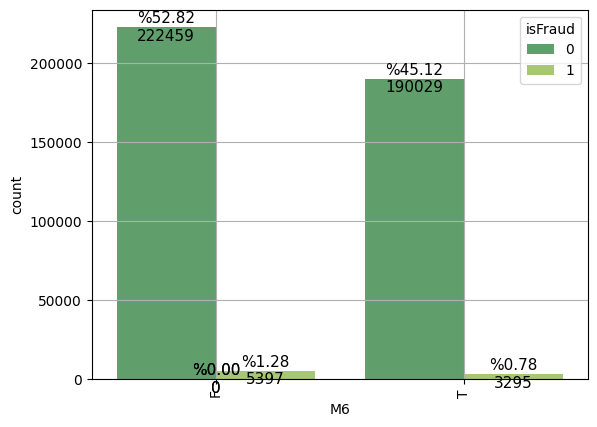

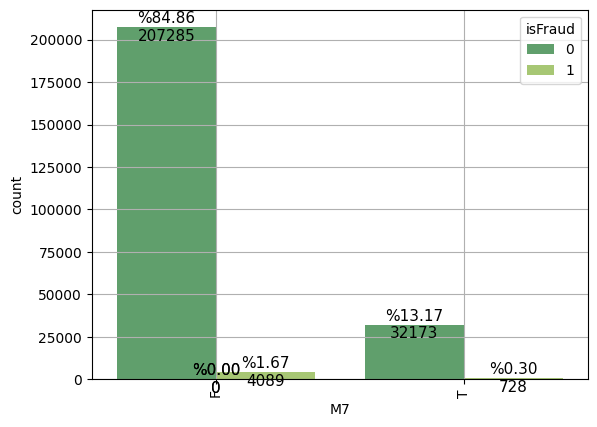

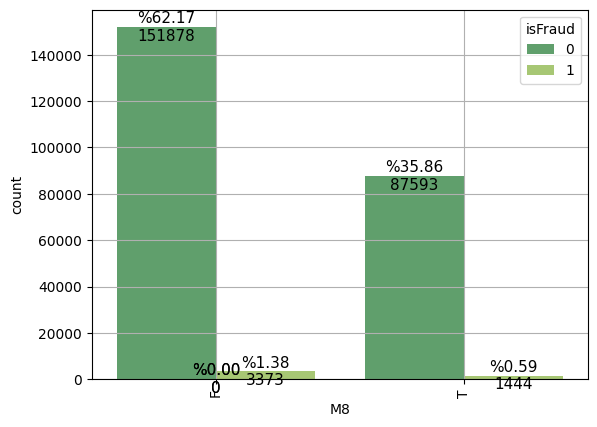

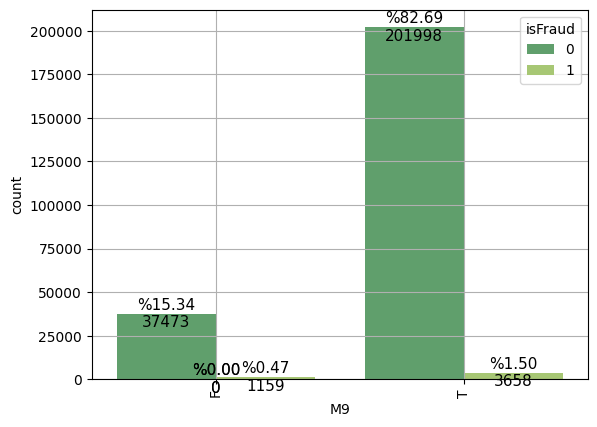

In [ ]:
m_cols = [m for m in train.columns if m[0] == 'M']

for col in m_cols:
    plot_col(col, df = train)
    plt.show()

- In M1 of all cases of T, 2% are fraudulant
- In M2 of all cases of F, 0.37% are fraudulant

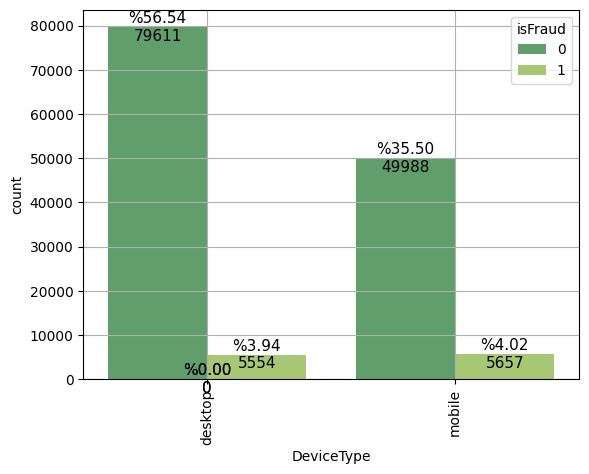

In [ ]:
plot_col('DeviceType',train)

-We can infer that fraudulent transactions mostly occur on mobile, though desktop is mostlt used for transactions

In [ ]:
tmp = train[['DeviceInfo','isFraud']].groupby(by=['DeviceInfo']).mean().sort_values(by='isFraud',ascending=False)
print(tmp[tmp['isFraud'] > 0.9].shape)
tmp[tmp['isFraud'] > 0.9]

(49, 1)


,isFraud
DeviceInfo,
ZTE-Z835,1.000000
Dream,1.000000
SM-T285M,1.000000
A5002,1.000000
A466BG,1.000000
SM-T530,1.000000
Blade L3 Build/KOT49H,1.000000
RNE-L23 Build/HUAWEIRNE-L23,1.000000
SAMSUNG-SM-N900A,1.000000


## 3. Data Preprocessing

### 3.1 Handle Missing Values

In [ ]:
#Missing Values Strategy
def get_missing_values_strategy(df):
    strategies = {}
    for column in df.columns:
        missing_pct = (df[column].isnull().sum() / len(df)) * 100
        
        if missing_pct == 0:
            strategies[column] = "No missing values"
        elif missing_pct > 70:
            strategies[column] = "Consider dropping column"
        elif df[column].dtype in ['int64', 'float64']:
            strategies[column] = "Fill with median/mean"
        else:
            strategies[column] = "Fill with mode or create missing category"
    
    return pd.Series(strategies)

print("\nSuggested Strategies for Handling Missing Values:")
print(get_missing_values_strategy(train))


Suggested Strategies for Handling Missing Values:
TransactionID            No missing values
isFraud                  No missing values
TransactionDT            No missing values
TransactionAmt           No missing values
ProductCD                No missing values
                            ...           
id_38             Consider dropping column
DeviceType        Consider dropping column
DeviceInfo        Consider dropping column
dayofweek                No missing values
hour                     No missing values
Length: 436, dtype: object


In [ ]:
train_null_percentages = pd.DataFrame((train.isnull().sum()/len(train))*100,columns = ['percentage'])
remove_features_identity = train_null_percentages[train_null_percentages['percentage']>50].index

#Columns count to be removed
print("Total count of columns to be removed:",len(remove_features_identity))

# Total number of fields
print("Total count of columns in identity data:",len(train_null_percentages))
train.shape

Total count of columns to be removed: 214
Total count of columns in identity data: 436


(590540, 436)

In [ ]:
null_pct = train[['R_emaildomain', 'DeviceType']].isnull().mean()
print(null_pct)

R_emaildomain    0.767516
DeviceType       0.761557
dtype: float64


In [ ]:
if 'DeviceType' in train.columns:
    # Handle missing values
    train['DeviceType'] = train['DeviceType'].fillna('unknown')

In [ ]:
if 'R_emaildomain' in train.columns:
    train['R_emaildomain'].fillna('Unknown', inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_7164\2138796617.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['R_emaildomain'].fillna('Unknown', inplace=True)


In [ ]:
# Drop columns with >50% missing values
threshold = 0.5
train.dropna(thresh=len(train)*threshold, axis=1, inplace=True)

# Impute numerical features with median
num_cols = train.select_dtypes(include=['float64', 'int64']).columns
train[num_cols] = train[num_cols].fillna(train[num_cols].median())

# Impute categorical features with mode
cat_cols = train.select_dtypes(include=['object']).columns
train[cat_cols] = train[cat_cols].fillna(train[cat_cols].mode().iloc[0])

In [ ]:
# #Correlation Analysis for Numerical Features
# numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns
# correlation_matrix = train[numerical_cols].corr()

# plt.figure(figsize=(15, 10))
# sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False)
# plt.title('Correlation Matrix of Numerical Features')
# plt.show()

### 3.2 Feature Engineering

In [ ]:
# Log-transform TransactionAmt to reduce skewness
train['TransactionAmt_Log'] = np.log1p(train['TransactionAmt'])

# Extract time features from TransactionDT (assumed to be seconds)
train['TransactionDT_Day'] = train['TransactionDT'] // (3600*24)

C:\Users\USER\AppData\Local\Temp\ipykernel_7164\955655380.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['TransactionAmt_Log'] = np.log1p(train['TransactionAmt'])
C:\Users\USER\AppData\Local\Temp\ipykernel_7164\955655380.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['TransactionDT_Day'] = train['TransactionDT'] // (3600*24)


In [ ]:
train.head(1)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V317,V318,V319,V320,V321,DeviceType,dayofweek,hour,TransactionAmt_Log,TransactionDT_Day
0,2987000,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,...,117.0,0.0,0.0,0.0,0.0,unknown,0,0,4.241327,1


### 3.3 Encode Categorical Features

In [ ]:
print("Columns after null handling:", train.columns.tolist())

Columns after null handling: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V9

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encoding for low-cardinality features
for col in ['ProductCD', 'DeviceType']:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))

# Frequency encoding for high-cardinality features
for col in ['P_emaildomain', 'R_emaildomain']:
    freq = train[col].value_counts(normalize=True)
    train[col + '_Freq'] = train[col].map(freq)

C:\Users\USER\AppData\Local\Temp\ipykernel_7164\2603398510.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col + '_Freq'] = train[col].map(freq)
C:\Users\USER\AppData\Local\Temp\ipykernel_7164\2603398510.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col + '_Freq'] = train[col].map(freq)


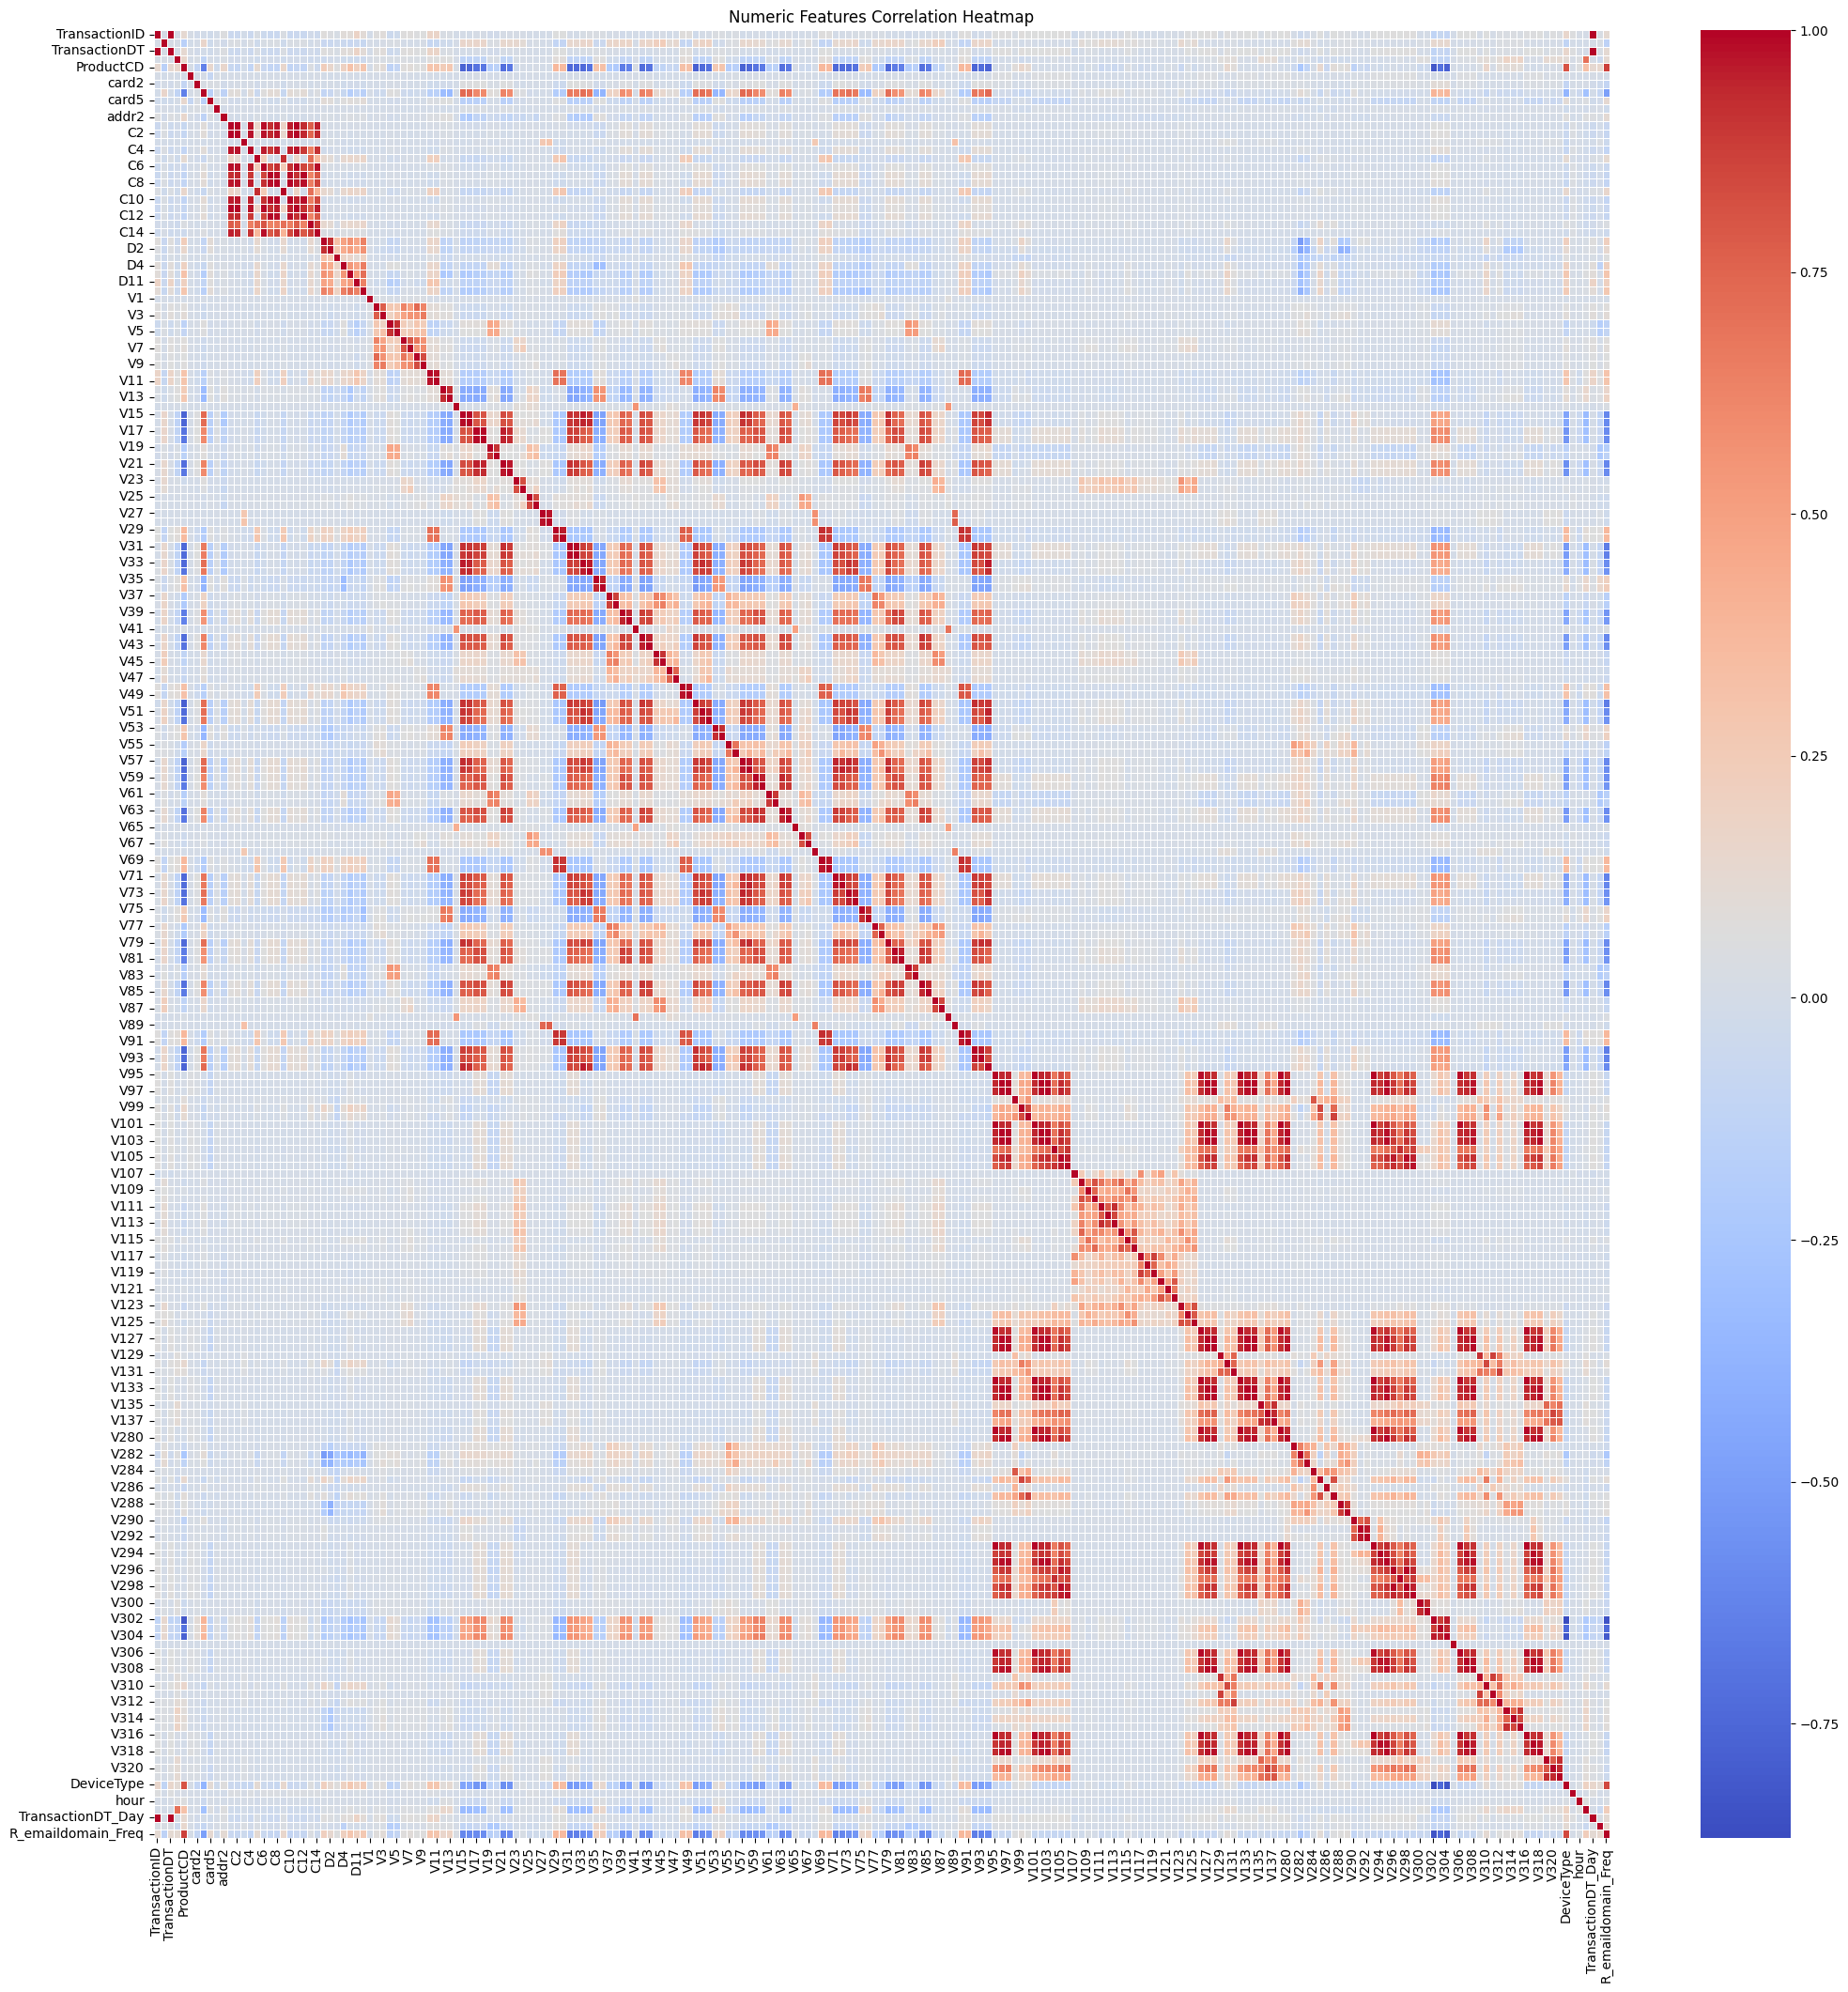

Top correlations with isFraud:
V45    0.235436
V86    0.222343
V87    0.221568
V44    0.217870
V52    0.195492
V51    0.182007
V40    0.174672
V79    0.167299
V39    0.166640
V38    0.165903
Name: isFraud, dtype: float64


In [ ]:
# Filter numeric columns only
numeric_cols = train.select_dtypes(include=['number']).columns
correlation_matrix = train[numeric_cols].corr()

plt.figure(figsize=(25, 25))
sns.heatmap(correlation_matrix, cmap='coolwarm', 
           annot=False, linewidths=0.5)  # Reduced visual clutter

plt.title('Numeric Features Correlation Heatmap')
plt.show()

# Show top correlations with target
print("Top correlations with isFraud:")
print(correlation_matrix['isFraud'].sort_values(ascending=False)[1:11])

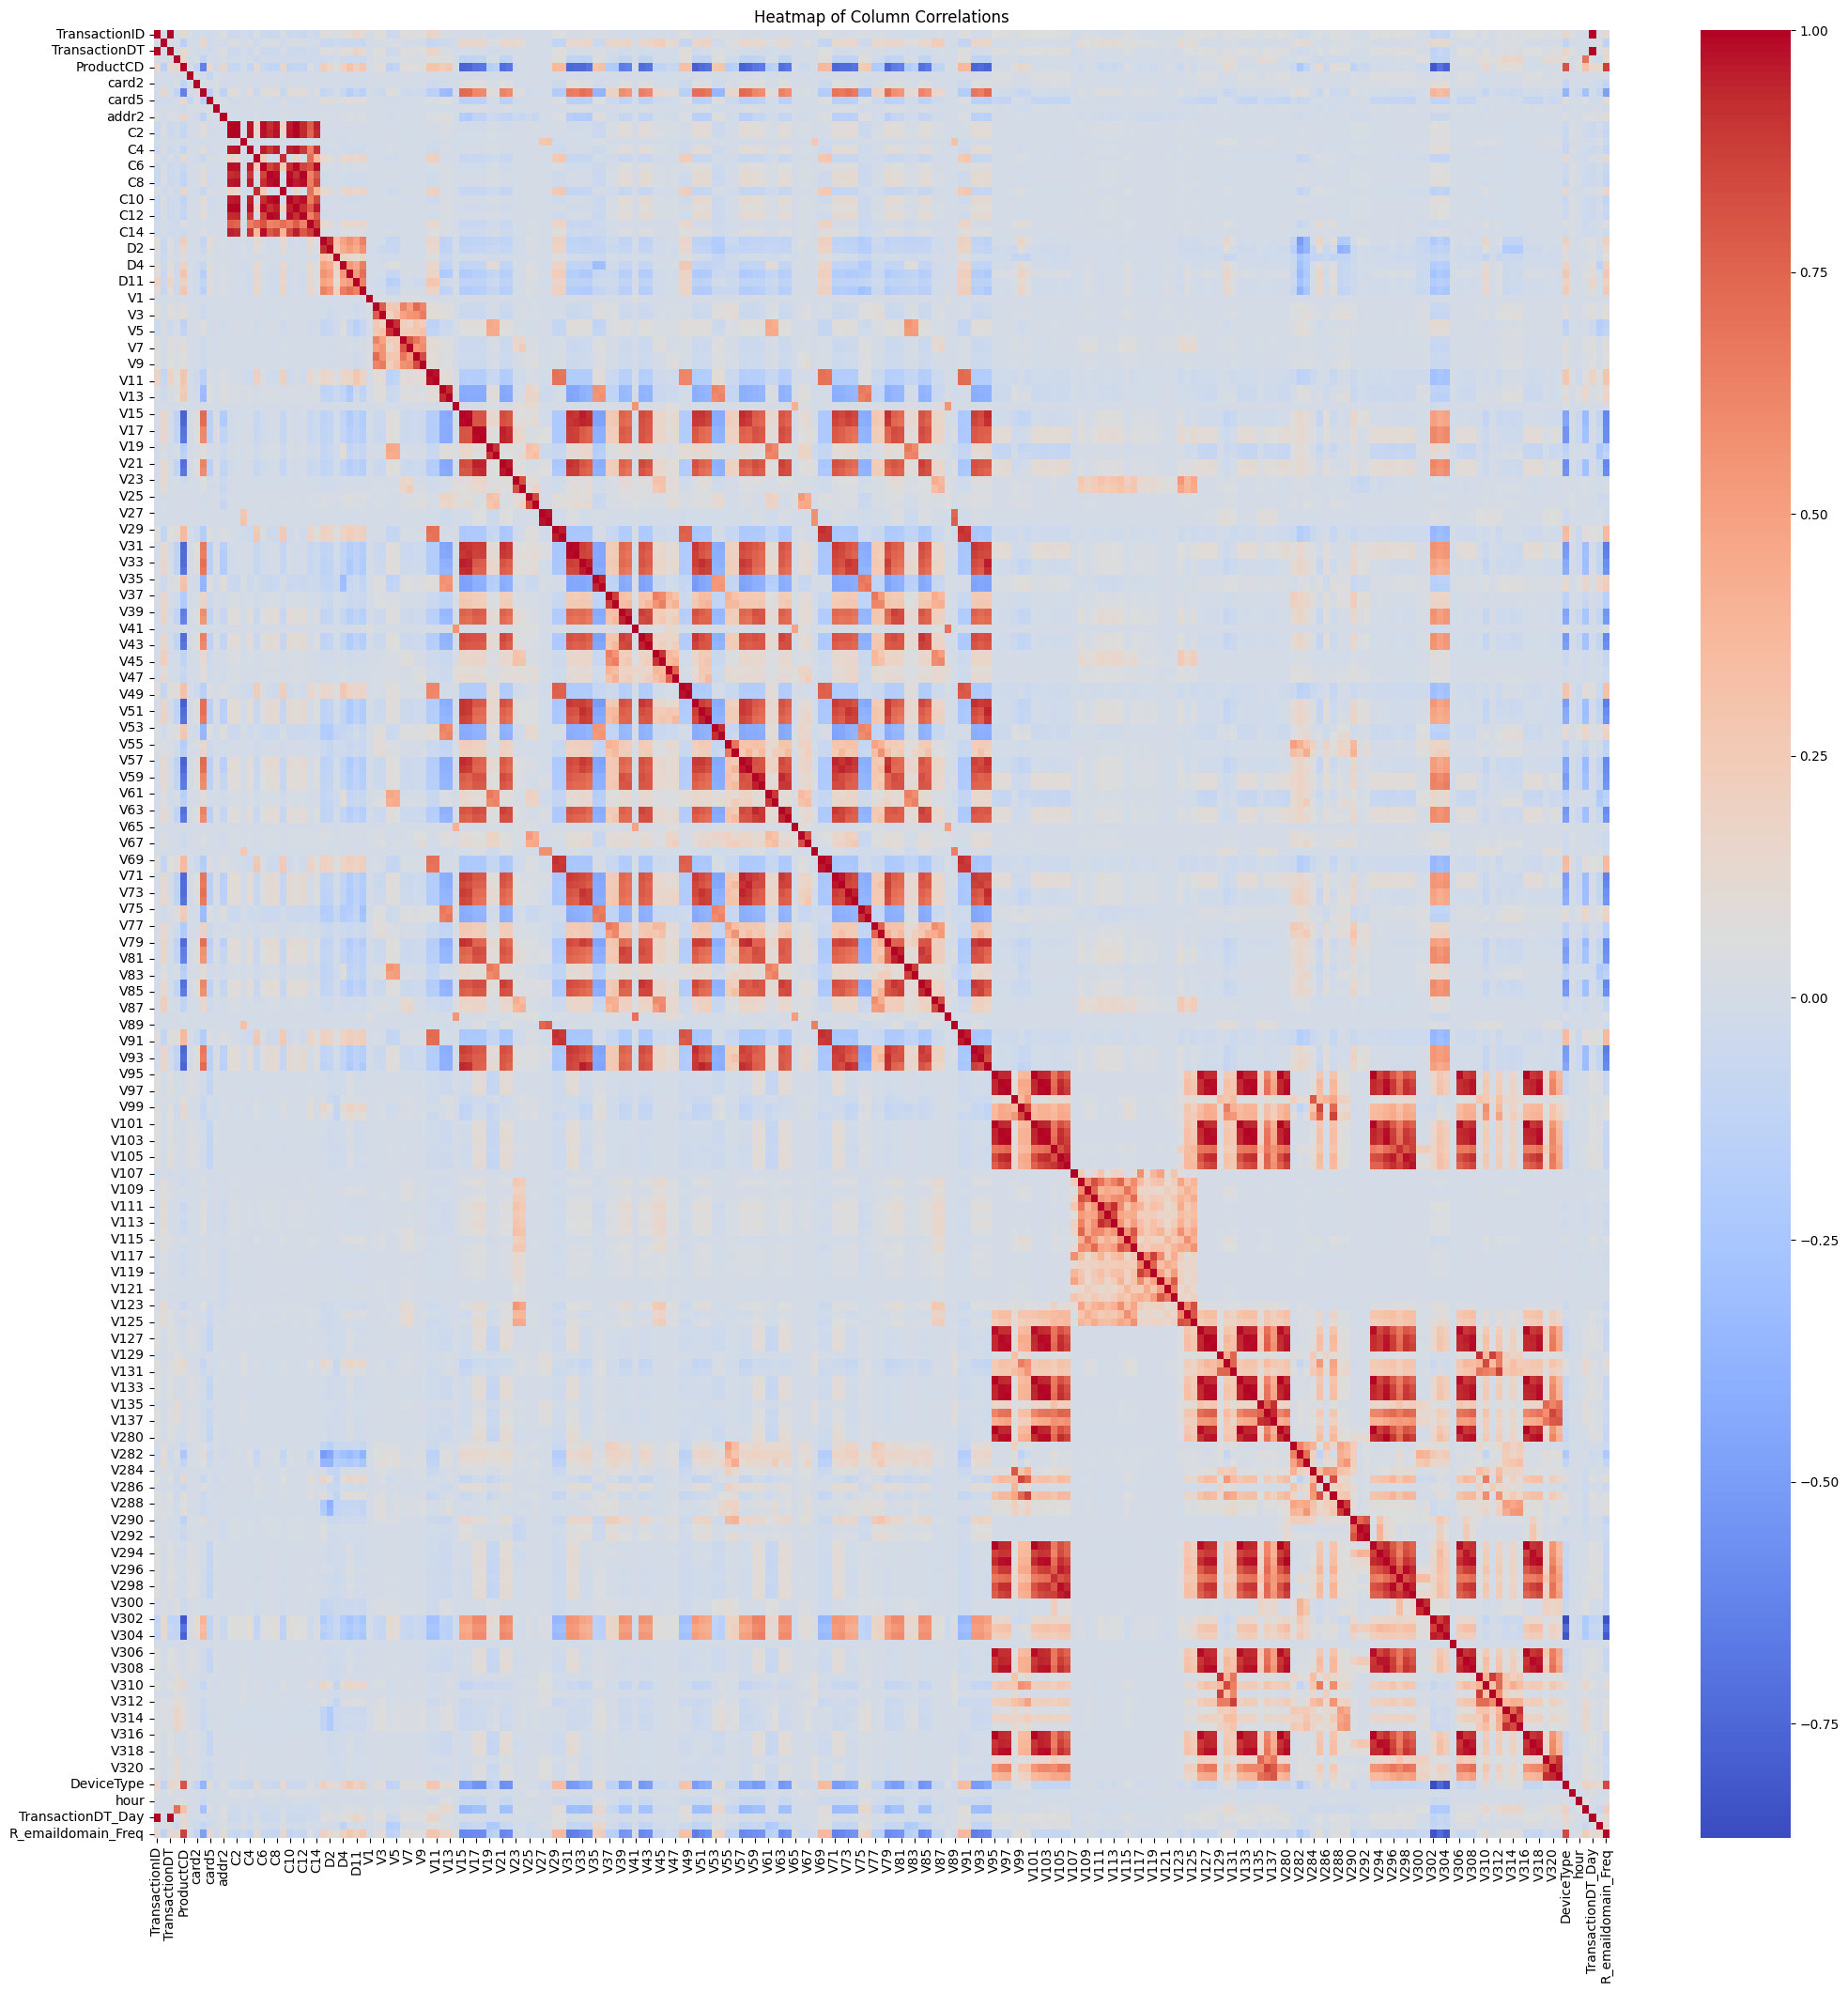

In [ ]:
# # correlation_matrix = train.drop('isFraud',axis=1).corr()
# plt.figure(figsize=(25, 25))
# sns.heatmap(correlation_matrix, cmap='coolwarm')

# plt.title('Heatmap of Column Correlations')
# plt.show()

## 4. Feature Scaling & PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Split features and target - Add numeric filtering
numeric_cols = train.select_dtypes(include=['number']).columns.tolist()
X = train[numeric_cols].drop(['isFraud', 'TransactionID', 'TransactionDT'], axis=1, errors='ignore')
y = train['isFraud']

# Handle missing values in numeric data
X = X.fillna(X.median())

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce dimensionality
pca = PCA(n_components=0.95)  # Retain 95% variance
X_pca = pca.fit_transform(X_scaled)
print(f"Reduced dimensions: {X_pca.shape[1]}")

# Create PCA dataframe for analysis
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df['isFraud'] = y.values

Reduced dimensions: 80


In [ ]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA

# # Split features and target
# X = train.drop(['isFraud', 'TransactionID', 'TransactionDT'], axis=1)
# y = train['isFraud']

# # Standardize features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Apply PCA to reduce dimensionality
# pca = PCA(n_components=0.95)  # Retain 95% variance
# X_pca = pca.fit_transform(X_scaled)
# print(f"Reduced dimensions: {X_pca.shape[1]}")

## 5. Handle Class Imbalance (SMOTE)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_pca, y)

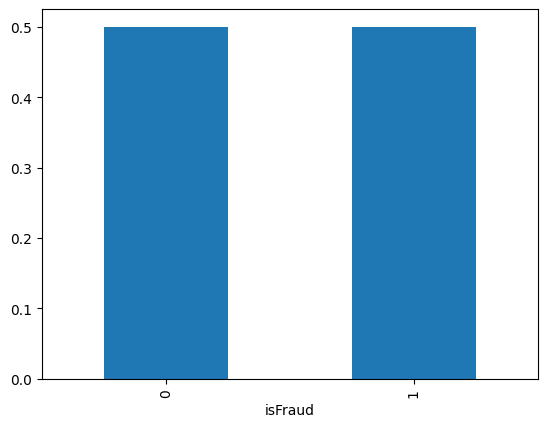

In [ ]:
temp_ser = y_res.value_counts(normalize=True)
temp_ser.plot(kind='bar')
plt.xlabel('isFraud')
plt.show()

In [ ]:
X_res.shape

(1139754, 80)

In [ ]:
train.shape

(590540, 228)

In [ ]:
train.drop_duplicates().shape

(590540, 228)

## 6. Model Training & Evaluation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.1, random_state=42)

In [ ]:
model = BalancedRandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    max_samples=0.5,
    n_jobs=-1,
    verbose=1,          # <--- ADD THIS
    random_state=42
)
model.fit(X_train, y_train)

In [ ]:
#Balanced Random Forest
# model = BalancedRandomForestClassifier(random_state=42)
# model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


In [ ]:
# Predict probabilities on the test set
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate the fpr, tpr, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate the AUC score
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC Score:", auc)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'r--', label='Random Guessing')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [ ]:
# Train XGBoost
model = XGBClassifier(scale_pos_weight=10, use_label_encoder=False, eval_metric='aucpr')
model.fit(X_train, y_train)

# Predict
y_pred = model.predict_proba(X_test)[:,1]

# Evaluate
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred):.4f}")
print(classification_report(y_test, model.predict(X_test)))

## 7. Model Interpretation

In [ ]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,15))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(20))
plt.title('Top 20 Important Features')
plt.show()